# Start Here

Welcome to the *Active Learning for bioacoustics* challenge.

This is an example notebook where you can evaluate your sampling method and export results for submissions. *You are free to adjust this notebook, however the results (.yaml) file must retain the correct format*.

Currently, this notebook runs the four baseline sampling strategies:
- `random` -- random sampling (challenge baseline)
- `margin_multilabel` -- uncertainty-based margin sampling
- `sklearn_coreset` -- diversity-based coreset selection
- `sklearn_typiclust` -- typicality clustering

**AULC** (Area Under the Learning Curve) for mAP (macro) is the primary metric:


In [1]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import time

PROJECT_ROOT = Path().absolute().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

from core.active_learner import ActiveLearner

core.active_learner - INFO - Pre-warming UMAP (triggering numba JIT compilation)...
core.active_learner - INFO - UMAP pre-warming completed in 6.110496520996094


## Step 1: Setup Configuration

In [2]:
# ---------------------------------------------------------------------------
# Active Learning Configuration
# ---------------------------------------------------------------------------

# Participant info:
AUTHOR_LASTNAME = 'baseline'      # NOTE: Lastname of the corresponding author
INSTITUTE_ABBREVIATION = 'BASEAL' # NOTE: Abbreviation of your institute or None

# AL loop parameters (Baseline default config)
N_CYCLES            = 15
EPOCHS_PER_CYCLE    = 10
BATCH_SIZE          = 32
N_SAMPLES_PER_CYCLE = 50    # NOTE: You can implement a scheduler

# Number of independent full-run repeats (each creates a fresh ActiveLearner
# with random model initialisation). Mean and SD are computed across these runs.
# NOTE: Submitted results must be run with N_REPEATS=5, use a lower value during development.
N_REPEATS = 2

# NOTE: Submitted results must be run with MAX_BUDGET=500.
MAX_BUDGET: int | None = None

# Warm-up samples before the AL loop (None = cold start)
PRETRAIN_SAMPLES: int | None = 50
WARMUP_STRATEGY = "density"  # warmup method: density | random | custom

# Baseline strategies to compare. NOTE: When you are ready, add your sampling method here.
STRATEGIES = [
    # "random",
    # "margin_multilabel",
    "sklearn_coreset",
    # "sklearn_typiclust",
]

print(f"Cycles            : {N_CYCLES}")
print(f"Samples per cycle : {N_SAMPLES_PER_CYCLE}")
print(f"Epochs per cycle  : {EPOCHS_PER_CYCLE}")
print(f"Outer repeats     : {N_REPEATS}  (independent runs, fresh model init each time)")
print(f"Max budget        : {MAX_BUDGET or 'none'}")
print(f"Strategies        : {STRATEGIES}")

Cycles            : 15
Samples per cycle : 50
Epochs per cycle  : 10
Outer repeats     : 2  (independent runs, fresh model init each time)
Max budget        : none
Strategies        : ['sklearn_coreset']


## Step 2: Dataset paths

Set paths for the dataset. Adjust for the BirdSet subsets (HSN, POW, UHH) or ATBFL dataset.

In [3]:
MODEL_NAME     = "birdnet"  # NOTE: Task 4 datasets will use "perch_v2" 
DATASET_NAME   = "ESC10_BASEAL"    # NOTE: download the Task 4 datasets and set the path e.g. "BirdSet_BASEAL/POW_BASEAL"

EMBEDDINGS_DIR = PROJECT_ROOT / DATASET_NAME / "embeddings" / MODEL_NAME
LABELS_PATH    = PROJECT_ROOT / DATASET_NAME / "labels.csv"

print(f"Embeddings : {EMBEDDINGS_DIR}")
print(f"Labels     : {LABELS_PATH}")
print(f"Dataset    : {DATASET_NAME}  |  Model: {MODEL_NAME}")

Embeddings : c:\Users\bmcewen\Documents\GitHub\BaseAL\ESC10_BASEAL\embeddings\birdnet
Labels     : c:\Users\bmcewen\Documents\GitHub\BaseAL\ESC10_BASEAL\labels.csv
Dataset    : ESC10_BASEAL  |  Model: birdnet


## Step 3: Run all baseline strategies

Each strategy runs the full AL loop with the shared configuration.
Results are collected in `results` for comparison and exported to `results/baselines/`.

In [4]:

results     = {}
all_learners = {}

OUTPUT_DIR = PROJECT_ROOT / "results" / "baselines"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

_dataset_info_printed = False

for strategy in STRATEGIES:
    print(f"\n{'='*60}")
    print(f"Strategy: {strategy}")
    print(f"{'='*60}")

    strategy_histories = []  # one training_history list per repeat

    for rep in range(N_REPEATS):
        print(f"\n  -- Repeat {rep + 1}/{N_REPEATS} --")

        # Fresh ActiveLearner each repeat -> random model re-initialisation.
        # repeats=1 disables the internal SD mechanism (handled by this outer loop).
        learner = ActiveLearner(
            embeddings_dir=EMBEDDINGS_DIR,
            annotations_path=LABELS_PATH,
            model_name=MODEL_NAME,
            dataset_name=DATASET_NAME,
            learning_rate=0.001,
            sampling_strategy=strategy,
            device="cpu",
            verbose=False,
            pretrain_samples=PRETRAIN_SAMPLES,
            warmup_strategy=WARMUP_STRATEGY,
        )

        if not _dataset_info_printed:
            state = learner.get_state()
            print(f"\n  Dataset: {DATASET_NAME}  |  Total: {state['n_labeled'] + state['n_unlabeled']}  |  Classes: {state['num_classes']}\n")
            _dataset_info_printed = True

        print(f"  {'Cycle':>5}  {'Labelled':>8}  {'mAP':>8}  {'AULC':>8}")
        print(f"  {'-'*38}")
        if learner.training_history and learner.training_history[0].get('warmup', False):
            w = learner.training_history[0]
            print(f"  {'warmup':>5}  {w['n_labeled']:>8}  {w['mAP']:>8.4f}  {w['aulc_mAP']:>8.4f}")

        for cycle in range(N_CYCLES):
            start = time.time()
            n_to_sample = N_SAMPLES_PER_CYCLE
            if MAX_BUDGET is not None:
                remaining = MAX_BUDGET - len(learner.labeled_indices)
                if remaining <= 0:
                    print(f"  Budget of {MAX_BUDGET} reached -- stopping.")
                    break
                n_to_sample = min(n_to_sample, remaining)

            selected = learner.sample(n_samples=n_to_sample)
            learner.add_samples(selected)
            metrics = learner.train_step(epochs=EPOCHS_PER_CYCLE, batch_size=BATCH_SIZE)
            print(f"  {cycle + 1:>5}  {metrics['n_labeled']:>8}  {metrics['mAP']:>8.4f}  {metrics['aulc_mAP']:>8.4f} {time.time() - start:>8.4f}")

        strategy_histories.append(learner.training_history)
        all_learners[strategy] = learner  # keep last for metadata

    results[strategy] = strategy_histories

    # Summary across repeats
    final_mAPs  = [h[-1]['mAP']       for h in strategy_histories]
    final_aulcs = [h[-1]['aulc_mAP']  for h in strategy_histories]
    print(f"\n  Final mAP : {np.mean(final_mAPs):.4f} +- {np.std(final_mAPs):.4f}")
    print(f"  Final AULC: {np.mean(final_aulcs):.4f} +- {np.std(final_aulcs):.4f}")


Strategy: sklearn_coreset

  -- Repeat 1/2 --


c:\Users\bmcewen\Documents\GitHub\BaseAL\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\bmcewen\Documents\GitHub\BaseAL\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\bmcewen\Documents\GitHub\BaseAL\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\bmcewen\AppData\Roaming\uv\python\cpython-3.12.13-windows-x86_64-none\Lib\subprocess.py", l


  Dataset: ESC10_BASEAL  |  Total: 640  |  Classes: 10

  Cycle  Labelled       mAP      AULC
  --------------------------------------
  warmup        50    0.5115    0.2558
      1       100    0.8771    0.4751   2.2867
      2       150    0.9157    0.6155   2.2502
      3       200    0.9255    0.6918   2.3766
      4       250    0.9160    0.7376   2.3847
      5       300    0.9401    0.7693   2.5679
      6       350    0.9428    0.7939   2.5312
      7       400    0.9293    0.8117   2.6238
      8       450    0.9323    0.8249   2.7740
      9       500    0.9345    0.8357   3.2984
     10       550    0.9354    0.8448   3.1832
     11       600    0.9230    0.8518   4.0966


core.active_learner - WARNING - No unlabeled samples remaining


     12       640    0.9179    0.8561   3.6135


...

     12       640    0.9235    0.8448   3.3656


core.active_learner - WARNING - No unlabeled samples remaining


     13       640    0.9212    0.8448   1.1331


core.active_learner - WARNING - No unlabeled samples remaining


     14       640    0.9159    0.8448   1.1325
     15       640    0.9150    0.8448   1.1839

  Final mAP : 0.9160 +- 0.0010
  Final AULC: 0.8504 +- 0.0057


## Step 4: Compare learning curves across strategies

In [5]:
def aggregate_histories(histories):
    """
    Aggregate a list of training histories (one per outer repeat) into
    per-cycle mean and SD.

    Args:
        histories: list of training_history lists, each of length N_CYCLES.

    Returns:
        List of dicts -- one entry per cycle -- with keys:
            cycle, n_labeled,
            mAP_mean, mAP_sd,
            aulc_mAP_mean, aulc_mAP_sd,
            annotation_cost,
            sampling_time_s_mean, sampling_time_s_sd
    """
    # Exclude warmup records (warmup=True) -- these have no training metrics
    histories = [[e for e in h if not e.get('warmup', False)] for h in histories]
    n_cycles = min(len(h) for h in histories)
    agg = []
    for c in range(n_cycles):
        entries = [h[c] for h in histories]
        mAPs  = np.array([e['mAP']         for e in entries])
        aulcs = np.array([e['aulc_mAP']    for e in entries])
        stimes = np.array([e.get('sampling_time_s', 0.0) for e in entries])
        agg.append({
            'cycle':              c + 1,
            'n_labeled':          entries[0]['n_labeled'],   # identical across repeats
            'mAP_mean':           float(np.mean(mAPs)),
            'mAP_sd':             float(np.std(mAPs)),
            'aulc_mAP_mean':      float(np.mean(aulcs)),
            'aulc_mAP_sd':        float(np.std(aulcs)),
            'annotation_cost':    entries[0].get('annotation_cost', 0),
            'sampling_time_s_mean': float(np.mean(stimes)),
            'sampling_time_s_sd':   float(np.std(stimes)),
        })
    return agg

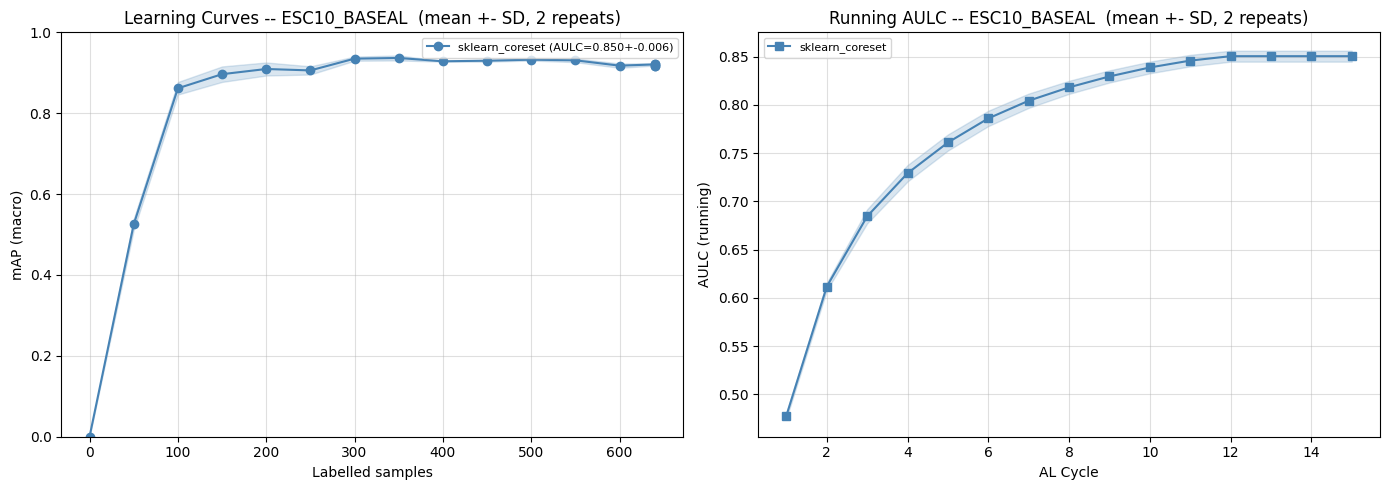


Final results -- ESC10_BASEAL  (2 outer repeats)
Strategy                            mAP (mean+-SD)     AULC (mean+-SD)
------------------------------------------------------------------------
sklearn_coreset                 0.9160 +-0.0010  0.8504 +-0.0057


In [6]:
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (strategy, histories), color in zip(results.items(), colors):
    agg = aggregate_histories(histories)

    # Include warmup anchor (pretrain_samples, 0.0) when warm-up was applied
    # Aggregate warmup mAP across repeats; origin always stays at (0, 0)
    _wu = [next((e for e in h if e.get('warmup', False)), None) for h in histories]
    _wu = [e for e in _wu if e is not None]
    if _wu:
        x_anchors  = [0, _wu[0]['n_labeled']]
        y_anchors  = [0.0, float(np.mean([e['mAP'] for e in _wu]))]
        sd_anchors = [0.0, float(np.std( [e['mAP'] for e in _wu]))]
    else:
        x_anchors  = [0]
        y_anchors  = [0.0]
        sd_anchors = [0.0]

    n_labeled   = np.array(x_anchors  + [a['n_labeled']    for a in agg])
    mAP_means   = np.array(y_anchors  + [a['mAP_mean']     for a in agg])
    mAP_sds     = np.array(sd_anchors + [a['mAP_sd']       for a in agg])
    aulc_means  = np.array([a['aulc_mAP_mean'] for a in agg])
    aulc_sds    = np.array([a['aulc_mAP_sd']  for a in agg])
    cycles      = np.arange(1, len(aulc_means) + 1)

    final_aulc_mean = agg[-1]['aulc_mAP_mean']
    final_aulc_sd   = agg[-1]['aulc_mAP_sd']
    label = f"{strategy} (AULC={final_aulc_mean:.3f}+-{final_aulc_sd:.3f})"

    # mAP learning curve
    axes[0].plot(n_labeled, mAP_means, marker='o', color=color, label=label)
    axes[0].fill_between(n_labeled,
                         mAP_means - mAP_sds,
                         mAP_means + mAP_sds,
                         alpha=0.2, color=color)

    # Running AULC curve
    axes[1].plot(cycles, aulc_means, marker='s', color=color, label=strategy)
    axes[1].fill_between(cycles,
                         aulc_means - aulc_sds,
                         aulc_means + aulc_sds,
                         alpha=0.2, color=color)

axes[0].set_xlabel('Labelled samples')
axes[0].set_ylabel('mAP (macro)')
axes[0].set_title(f'Learning Curves -- {DATASET_NAME}  (mean +- SD, {N_REPEATS} repeats)')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

axes[1].set_xlabel('AL Cycle')
axes[1].set_ylabel('AULC (running)')
axes[1].set_title(f'Running AULC -- {DATASET_NAME}  (mean +- SD, {N_REPEATS} repeats)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f"\nFinal results -- {DATASET_NAME}  ({N_REPEATS} outer repeats)")
print(f"{'Strategy':<30}  {'mAP (mean+-SD)':>18}  {'AULC (mean+-SD)':>18}")
print("-" * 72)
for strategy, histories in results.items():
    agg = aggregate_histories(histories)
    final = agg[-1]
    print(f"{strategy:<30}  {final['mAP_mean']:>6.4f} +-{final['mAP_sd']:>6.4f}  "
          f"{final['aulc_mAP_mean']:>6.4f} +-{final['aulc_mAP_sd']:>6.4f}")

## Step 5: Exported files

Each strategy's results are written to `results/baselines/` as a YAML file.
Inspect these to determine an appropriate `MAX_BUDGET` and confirm baseline performance.

In [7]:
import yaml
from datetime import datetime

_BASELINE_EPOCHS     = 10
_BASELINE_BATCH_SIZE = 32


def export_aggregated(strategy, histories, learner, output_path, max_budget=None):
    """
    Export aggregated (mean +- SD across outer repeats) results as a YAML file.

    The per-cycle learning curve contains mAP and AULC mean/SD, with the warmup
    step included as cycle 0. Supplementary fields include total annotation cost
    and sampling wall-time (mean +- SD across repeats) computed over all history
    entries (warmup + AL cycles) and the standard computational cost ratio.
    """
    agg = aggregate_histories(histories)
    model_parameters = int(sum(p.numel() for p in learner.model.parameters()))
    n_cycles = len(agg)
    epochs_per_cycle = EPOCHS_PER_CYCLE

    # Warmup entries (one per outer repeat)
    warmup_entries = [next((e for e in h if e.get('warmup', False)), None) for h in histories]
    warmup_entries = [e for e in warmup_entries if e is not None]

    # Per-cycle rows: warmup as cycle 0, then AL cycles
    learning_curve = []
    if warmup_entries:
        wu_stimes = [e.get('sampling_time_s', 0.0) for e in warmup_entries]
        learning_curve.append({
            'cycle':                 0,
            'warmup':                True,
            'n_labeled':             warmup_entries[0]['n_labeled'],
            'mAP_mean':              round(float(np.mean([e['mAP']      for e in warmup_entries])), 6),
            'mAP_sd':                round(float(np.std( [e['mAP']      for e in warmup_entries])), 6),
            'aulc_mAP_mean':         round(float(np.mean([e['aulc_mAP'] for e in warmup_entries])), 6),
            'aulc_mAP_sd':           round(float(np.std( [e['aulc_mAP'] for e in warmup_entries])), 6),
            'annotation_cost':       warmup_entries[0].get('annotation_cost', 0),
            'sampling_time_s_mean':  round(float(np.mean(wu_stimes)), 6),
            'sampling_time_s_sd':    round(float(np.std(wu_stimes)),  6),
        })

    for a in agg:
        learning_curve.append({
            'cycle':                 a['cycle'],
            'n_labeled':             a['n_labeled'],
            'mAP_mean':              round(a['mAP_mean'],          6),
            'mAP_sd':                round(a['mAP_sd'],            6),
            'aulc_mAP_mean':         round(a['aulc_mAP_mean'],     6),
            'aulc_mAP_sd':           round(a['aulc_mAP_sd'],       6),
            'annotation_cost':       a['annotation_cost'],
            'sampling_time_s_mean':  round(a['sampling_time_s_mean'], 6),
            'sampling_time_s_sd':    round(a['sampling_time_s_sd'],   6),
        })

    # Aggregate annotation cost and sampling time across ALL history entries (warmup + AL cycles)
    total_ann_costs = [
        sum(e.get('annotation_cost', 0) for e in h)
        for h in histories
    ]
    total_stimes = [
        sum(e.get('sampling_time_s', 0.0) for e in h)
        for h in histories
    ]

    # Computational cost
    baseline_n_cycles = max_budget // _BASELINE_BATCH_SIZE if max_budget else n_cycles
    cost_method   = model_parameters * epochs_per_cycle * n_cycles
    baseline_cost = model_parameters * _BASELINE_EPOCHS * baseline_n_cycles
    relative_cost = round(cost_method / baseline_cost, 4) if baseline_cost > 0 else None

    submission = {
        'submission_timestamp':   datetime.now().isoformat(timespec='seconds'),
        'author_lastname':        AUTHOR_LASTNAME,
        'institute_abbreviation': INSTITUTE_ABBREVIATION,
        'sampling_strategy':      strategy,
        'dataset':                DATASET_NAME,
        'model':                  MODEL_NAME,
        'config': {
            'learning_rate':      learner.learning_rate,
            'model_parameters':   model_parameters,
            'n_outer_repeats':    N_REPEATS,
            'pretrain_samples':   learner.pretrain_samples,
            'warmup_strategy':   learner.warmup_strategy.method,
        },
        'learning_curve': learning_curve,
        'supplementary': {
            'n_cycles':                       n_cycles,
            'n_outer_repeats':                N_REPEATS,
            'total_annotation_cost_mean':     round(float(np.mean(total_ann_costs)), 2),
            'total_annotation_cost_sd':       round(float(np.std(total_ann_costs)),  2),
            'total_sampling_time_s_mean':     round(float(np.mean(total_stimes)),    6),
            'total_sampling_time_s_sd':       round(float(np.std(total_stimes)),     6),
            'computational_cost': {
                'model_parameters':   model_parameters,
                'epochs_per_cycle':   epochs_per_cycle,
                'n_cycles':           n_cycles,
                'cost_method':        cost_method,
                'baseline_n_cycles':  baseline_n_cycles,
                'baseline_cost':      baseline_cost,
                'relative_cost':      relative_cost,
            },
        },
    }

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, 'w') as f:
        yaml.dump(submission, f, default_flow_style=False, sort_keys=False, allow_unicode=True)
    print(f"  Saved: {Path(output_path).name}")


print(f"Files saved to: {PROJECT_ROOT / 'results' / 'baselines'}\n")
for strategy in STRATEGIES:
    safe_name = DATASET_NAME.replace('/', '_')
    output_file = OUTPUT_DIR / f"{strategy}_{safe_name}.yaml"
    export_aggregated(
        strategy=strategy,
        histories=results[strategy],
        learner=all_learners[strategy],
        output_path=str(output_file),
        max_budget=MAX_BUDGET,
    )

Files saved to: c:\Users\bmcewen\Documents\GitHub\BaseAL\results\baselines

  Saved: sklearn_coreset_ESC10_BASEAL.yaml


## Notes

- `MAX_BUDGET = None` the loop runs for exactly `N_CYCLES`
- `N_SAMPLES_PER_CYCLE` samples with no cap.
  Set `MAX_BUDGET` to a specific value once an appropriate budget has been determined from these results.
- All four strategies use the same `learning_rate`, `epochs`, and `batch_size` to ensure fair comparison.
- The YAML exports in `results/baselines/` contain the full learning curve and can be used to set
  `MAX_BUDGET` in the challenge participant notebooks.